1. import data 
2. clean the data 
3. data normalization
4. set the random seed 
5. define the nonlinear model 
6. define the loss function , optimizer
7. training the loops
8. visualize the plot, evaluate the performance
9. estimate the new value



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


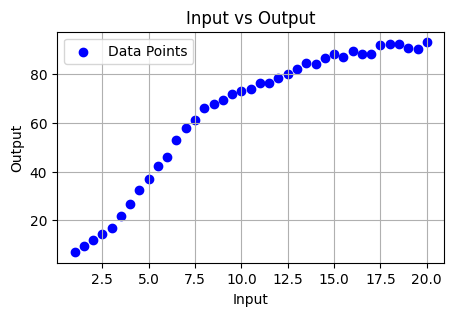

In [21]:
## Magic cmd to automatically reload modules when they have been changed.
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
# This line ensures that your results are reproducible and consistent every time.
torch.manual_seed(42)
import matplotlib.pyplot as plt
from plot_support import plot_numpyarr
from plot_support import plot_regression_line, dynamic_plot

input_train_arr = np.array([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]])
# input_arr.shape
output_train_arr = np.array([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
    ]
    )
input_train_tensor = torch.tensor(input_train_arr, dtype=torch.float32)
output_train_tensor = torch.tensor(output_train_arr, dtype=torch.float32)
input_train_tensor.shape

plot_numpyarr(input_train_arr, output_train_arr)


In [14]:
# tensor obj has method like .mean(), .std(). 
# we are going to normalize the data
input_mean = input_train_tensor.mean()
input_std = input_train_tensor.std()
output_mean = output_train_tensor.mean()
output_std = output_train_tensor.std()
input_train_norm = (input_train_tensor - input_mean) / input_std
output_train_norm = (output_train_tensor - output_mean) / output_std
# plot_numpyarr(input_train_norm.numpy(), output_train_norm.numpy())

Epoch [1000/5000], Loss: 0.0086


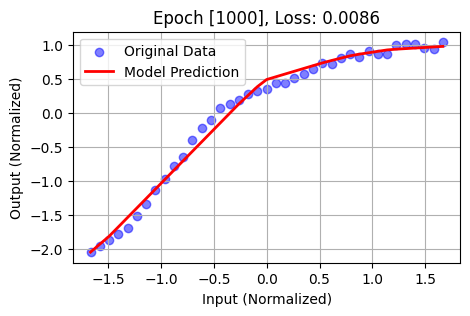

Epoch [2000/5000], Loss: 0.0043


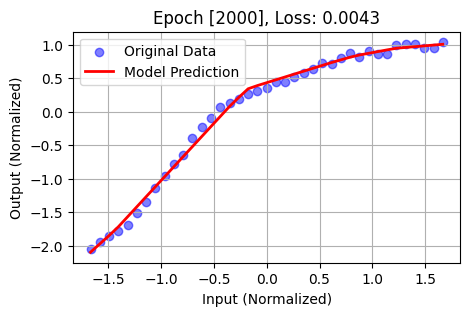

Epoch [3000/5000], Loss: 0.0027


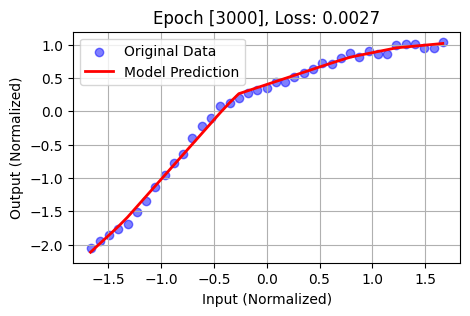

Epoch [4000/5000], Loss: 0.0021


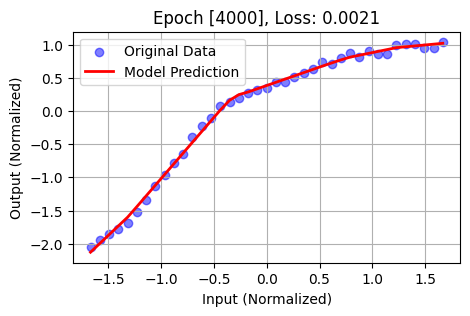

Epoch [5000/5000], Loss: 0.0019


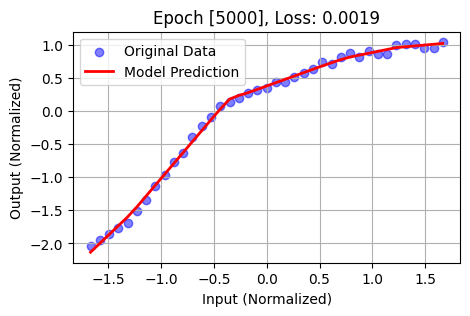

In [18]:
# Now let's keep result fixed 
torch.random.manual_seed(42)

# defining the model
model = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=1)
)

# defining the loss function and the optimizer
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

#training loop
num_epochs = 5000
for epoch in range(num_epochs):
    # set the model to training mode, which is the default mode
    model.train()
    # every time before backward, we need to zero the gradients
    optimizer.zero_grad()
    
    predictions = model(input_train_norm)
    loss = loss_fn(predictions, output_train_norm)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        dynamic_plot(model, x = input_train_norm, y_true = output_train_norm, y_pred = predictions, epoch=epoch+1, loss=loss.item())

# plot_regression_line(x = input_train_norm, y_true = output_train_norm, y_pred = predictions, title="Regression Plot")

In [19]:
# Let's test the new data , say input = 12.0
input_test = torch.tensor([[12.0]], dtype=torch.float32)
# normalize the test data
input_test_norm = (input_test - input_mean) / input_std
# get the estimated output
output_test_norm = model(input_test_norm)
# denormalize the output
output_test = output_test_norm * output_std + output_mean
print(f'For input {input_test.item():.2f}, the model predicts output {output_test.item():.2f}')


For input 12.00, the model predicts output 78.76
